# Fate marker example

End-to-end walkthrough of the organoid pipeline for **one** organoid, addressed by its
master uid (e.g. `main_dataset_day4p5_A06_11`) exactly the way `inspect_embedding.py` and
`Data/npz/master.npz` refer to organoids.

This notebook:
1. resolves a master uid to its `.vtp` mesh in `Data/<dataset>/vtp/<timepoint>/`,
2. runs the **full processing pipeline** of `run_new_meshes.py` (load → refine fates →
   PCA align → eigendecomposition → spherical-harmonic coefficients) and the per-organoid
   feature extraction of `compute_master_npz.py` (reconstruction quality, complexity /
   `l_cross`, HKS coefficients, bag-of-features),
3. **reconstructs** the shape at increasing harmonic degree and saves the meshes as STLs
   under `sim/`,
4. shows the different **per-vertex encodings** on the organoid (cell fates, HKS,
   bag-of-features words) and writes them all onto a single `.vtp` under `sim/`,
5. keeps the existing fate/HKS correlation and bag-of-features visualisations.

Fate fields are refined with `FateMarkers._refine_markers`, which combines multi-channel
markers (e.g. `ta` = cycd or cyca) and applies the biological mutual-exclusion hierarchy
defined in each dataset's `config.json`.

In [51]:
import os
import json

import igl
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
from meshplot import plot
from matplotlib import pyplot as plt

from src.fatemarkers import FateMarkers

## Pick an organoid by its master uid

A master uid is `'{dataset}_{timepoint}_{well}_{label}'` (the same string stored in
`Data/npz/master.npz['ids']`). We strip the known dataset prefix to recover the mesh's filename
stem `'{timepoint}_{well}_{label}'`, then locate the `.vtp` under the dataset's `vtp_flat`
layout: `Data/<dataset>/vtp/<timepoint>/<stem>.vtp`. Both `main_dataset` and `sup_dataset`
use this layout.

In [52]:
DATA_ROOT = 'Data'
DATASETS  = ['main_dataset', 'sup_dataset']

uid = 'main_dataset_day4p5-more_C03_161'   # any id from Data/npz/master.npz['ids']
# uid = 'main_dataset_day4p5_A06_11'   # any id from Data/npz/master.npz['ids']
# uid = 'main_dataset_day2_A04_59'


def resolve_uid(uid, datasets=DATASETS, data_root=DATA_ROOT):
    """master uid -> (dataset, timepoint, stem, vtp_path). Assumes the vtp_flat layout."""
    for ds in sorted(datasets, key=len, reverse=True):   # longest prefix wins
        if uid.startswith(ds + '_'):
            stem      = uid[len(ds) + 1:]                 # 'day4p5_A06_11'
            timepoint = stem.split('_')[0]                # 'day4p5'
            vtp       = f'{data_root}/{ds}/vtp/{timepoint}/{stem}.vtp'
            return ds, timepoint, stem, vtp
    raise ValueError(f'{uid!r} does not start with any known dataset prefix {datasets}')


dataset, timepoint, stem, vtp_path = resolve_uid(uid)
assert os.path.exists(vtp_path), f'mesh not found: {vtp_path}'

with open(f'{DATA_ROOT}/{dataset}/config.json') as f:
    cfg = json.load(f)
annotation_names = cfg['annotation_names']   # friendly name -> vtp field(s)
exclusion_rules  = cfg['exclusion_rules']    # biological mutual-exclusion hierarchy
fate_order       = list(annotation_names.keys())

print('dataset  :', dataset)
print('timepoint:', timepoint)
print('mesh     :', vtp_path)
print('fates    :', fate_order)

dataset  : main_dataset
timepoint: day4p5-more
mesh     : Data/main_dataset/vtp/day4p5-more/day4p5-more_C03_161.vtp
fates    : ['lgr', 'chroma', 'ta', 'muc', 'aldob', 'gluc', 'agr', 'sero', 'lyz']


## Full processing pipeline (`run_new_meshes.py`)

These are exactly the steps `run_new_meshes.run_fatemarkers` runs per mesh before saving the
`_coeffs.npz` / `_transformed_mesh.obj` that the rest of the pipeline consumes. Running them
here reproduces the saved coefficients for this organoid.

In [53]:
m = FateMarkers()
m.load_mesh_from_file(vtp_path)
m._refine_markers(annotation_names, exclusion_rules)   # combine 'ta' channels + mutual exclusion
m.align_with_pca()                                     # PCA-align, deterministic axis signs
m.precompute_eigens(lmax=15)                           # Laplace-Beltrami eigendecomposition
m.compute_coefficients(fate=True)                      # sph-harm coeffs of shape + fate fields

print('area       :', float(m.area))
print('vertices   :', m.v.shape[0], '| faces:', m.f.shape[0])
print('lmax       :', m.lmax, '| modes:', m.modes.shape[1])
print('recon qual :', float(m.compute_recon_quality()), '(lower = better)')

area       : 386.3177593860047
vertices   : 18001 | faces: 35998
lmax       : 15 | modes: 225
recon qual : 0.001848030473499915 (lower = better)


## Per-organoid features (`compute_master_npz.py`)

The master npz stores, per organoid, the incremental reconstruction error at `lmax = 0..8`
(column `i` = reconstruction including SH degrees `0..i`), the interpolated max degree
`l_cross` where that error crosses a threshold, and the HKS coefficients at a few fixed
diffusion times. The helpers below are the same ones in `compute_master_npz.py`.

complexity errors (lmax 0..8): [0.3052 0.0528 0.0372 0.0314 0.0211 0.0162 0.0114 0.0085 0.0056]
l_cross                      : 8.0
HKS sparse coeffs shape      : (225, 4)


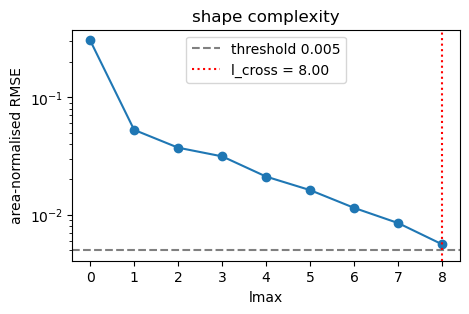

In [54]:
SPARSE_TS         = [1, 4, 25, 100]
COMPLEXITY_LMAX   = 9
L_CROSS_THRESHOLD = 0.005


def compute_complexity_errors(m):
    """Reconstruction RMSE (area-normalised) at lmax=0..8 (col i = SH degrees 0..i),
    accumulating one degree band at a time."""
    recon, errors = np.zeros_like(m.v), []
    for l in range(1, COMPLEXITY_LMAX + 1):
        lo, hi = (l - 1) ** 2, l ** 2
        recon += m.modes[:, lo:hi] @ m.coeffs_v[lo:hi, :]
        diff = m.v - recon
        errors.append(np.sqrt(np.einsum('ij,ij->', diff, diff) / m.v.shape[0]) / np.sqrt(m.area))
    return np.array(errors)


def compute_l_cross(errs):
    """Interpolated lmax (max SH degree) where the recon error crosses L_CROSS_THRESHOLD."""
    lmax_max = COMPLEXITY_LMAX - 1
    if errs[-1] > L_CROSS_THRESHOLD:
        return float(lmax_max)
    return float(np.interp(L_CROSS_THRESHOLD, errs[::-1], np.arange(lmax_max, -1, -1)))


complexity_errors = compute_complexity_errors(m)
l_cross           = compute_l_cross(complexity_errors)
hks_sparse_coeffs = m.compute_hks_for_new_times(SPARSE_TS, coeffs=True)   # (n_modes^2, 4)

print('complexity errors (lmax 0..8):', np.round(complexity_errors, 4))
print('l_cross                      :', round(l_cross, 3))
print('HKS sparse coeffs shape      :', hks_sparse_coeffs.shape)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(COMPLEXITY_LMAX), complexity_errors, 'o-')
plt.axhline(L_CROSS_THRESHOLD, color='grey', ls='--', label=f'threshold {L_CROSS_THRESHOLD}')
plt.axvline(l_cross, color='red', ls=':', label=f'l_cross = {l_cross:.2f}')
plt.yscale('log')
plt.xlabel('lmax'); plt.ylabel('area-normalised RMSE'); plt.legend(); plt.title('shape complexity')
plt.show()

## Reconstruction → STL

Reconstruct the organoid surface from its harmonic coefficients at increasing degree and save
each as an STL under `sim/recon_<uid>/`. Low `lmax` keeps only coarse shape; higher `lmax`
adds finer detail (compare with `l_cross` above).

In [55]:
recon_dir = f'sim/recon_{uid}'
os.makedirs(recon_dir, exist_ok=True)

np.save(f'{recon_dir}/complexity_errors_{uid}.npy', complexity_errors)

for lmax in [1, 2, 4, 6, 14]:
    recon = m.reconstruct_from_coeffs(m.coeffs_v, lmax=lmax+1)   # (n_vertices, 3)
    out = f'{recon_dir}/recon_lmax{lmax:02d}.stl'
    igl.write_triangle_mesh(out, np.ascontiguousarray(recon), m.f)
    print(f'lmax={lmax:2d}  ->  {out}')
    plot(recon, m.f)

lmax= 1  ->  sim/recon_main_dataset_day4p5-more_C03_161/recon_lmax01.stl


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-1.241204…

lmax= 2  ->  sim/recon_main_dataset_day4p5-more_C03_161/recon_lmax02.stl


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.296658…

lmax= 4  ->  sim/recon_main_dataset_day4p5-more_C03_161/recon_lmax04.stl


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.507472…

lmax= 6  ->  sim/recon_main_dataset_day4p5-more_C03_161/recon_lmax06.stl


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.435095…

lmax=14  ->  sim/recon_main_dataset_day4p5-more_C03_161/recon_lmax14.stl


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.260903…

## Encoding 1 — cell fates on the surface

Each fate marker, in the canonical `fate_order`, plotted on the mesh. `ta` is the combined
cell-cycle channel appended by `_refine_markers`.

In [56]:
def fate_index(name):
    """Column of fate `name` in m.fields (list-valued markers like 'ta' are combined into one)."""
    fld = annotation_names[name]
    return m.field_names.index(name if isinstance(fld, list) else fld)


fate_fields = {name: m.fields[:, fate_index(name)] for name in fate_order}
for name, vals in fate_fields.items():
    print(f'{name:8s}  positive vertices: {int((vals > 0).sum()):6d}')
    plot(m.v, m.f, c=vals)

lgr       positive vertices:    160


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

chroma    positive vertices:    205


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

ta        positive vertices:   3210


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

sero      positive vertices:    302


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

lyz       positive vertices:      0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

## Encoding 2 — heat-kernel signature (HKS)

HKS at a series of diffusion times (time ~ distance squared); larger times probe larger
neighbourhoods around each vertex.

In [57]:
hks = m.compute_hks_for_new_times(SPARSE_TS, coeffs=False)   # (n_vertices, len(SPARSE_TS))
print('hks shape:', hks.shape)

for k, t in enumerate(SPARSE_TS):
    print(f'HKS at t={t}')
    plot(m.v, m.f, c=hks[:, k])

hks shape: (18001, 4)
HKS at t=1


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

HKS at t=4


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

HKS at t=25


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

HKS at t=100


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

## Fate / HKS correlation

Spherical-harmonic coefficients of the fate fields and of the HKS fields, compared via a
mass-weighted correlation (ignoring the degree-0 / mean term).

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_2909/2512066209.py:14: RuntimeWarning: invalid value encountered in scalar divide
  corr_matrix[i, j] = corr / np.sqrt(var_i * var_j)


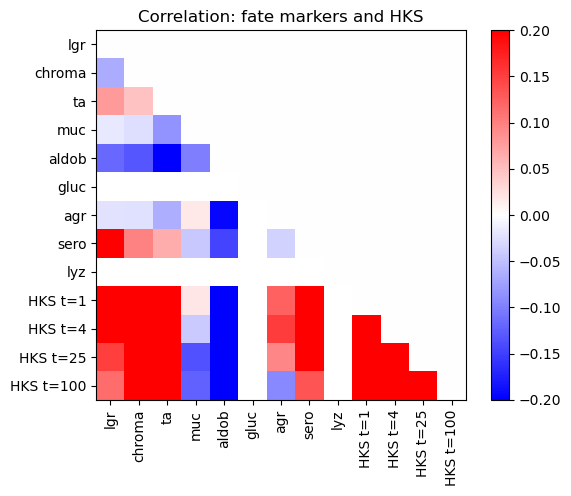

In [58]:
coeffs_fm  = m.coeffs_fm[:, [fate_index(n) for n in fate_order]]
hks_coeffs = m.compute_hks_for_new_times(SPARSE_TS, coeffs=True)
coeffs = np.concatenate([coeffs_fm, hks_coeffs], axis=1)

labels = fate_order + [f'HKS t={t}' for t in SPARSE_TS]
area = m.mass_matrix.diagonal().sum()

corr_matrix = np.zeros((coeffs.shape[1], coeffs.shape[1]))
for i in range(coeffs.shape[1]):
    for j in range(i + 1, coeffs.shape[1]):
        corr  = np.sum(coeffs[1:, i] * coeffs[1:, j]) / area
        var_i = np.sum(coeffs[1:, i] ** 2) / area
        var_j = np.sum(coeffs[1:, j] ** 2) / area
        corr_matrix[i, j] = corr / np.sqrt(var_i * var_j)

plt.imshow(corr_matrix.T, cmap='bwr', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)
plt.title('Correlation: fate markers and HKS')
plt.show()

## Encoding 3 — bag-of-features

Soft-assign each vertex's multi-scale HKS curve to a learned vocabulary of shape "words". This
is the `kmeans_variable` vocabulary used by `compute_master_npz.py`: HKS is sampled at
area-dependent ("variable") diffusion times, normalised, then soft-assigned to each cluster
centre.

In [59]:
def find_times(area, n):
    final_time = np.sqrt(area)
    return np.exp(2 * np.linspace(0, np.log(final_time), n))


def hks_unit_area(m, ts):
    eigvecs = m.eigvecs * np.sqrt(m.area)
    hks = np.array([np.einsum('i,ji->j', np.exp(-m.eigvals * t), eigvecs ** 2) for t in ts]).T
    return hks / np.mean(hks, axis=0) - 1


res    = np.load('sim/vocab_variable_time.npz', allow_pickle=True)
vocab  = res['vocab']
scaler = res['scaler'].item()
sigma  = float(res['sigma'])

N_VARIABLE_TS = vocab.shape[1] 

vocab_ts       = find_times(m.area, N_VARIABLE_TS)
normalised_hks = scaler.transform(hks_unit_area(m, vocab_ts))

# soft-assignment of each vertex to each vocab word
dist     = np.linalg.norm(normalised_hks[:, None, :] - vocab[None, :, :], axis=2)
encoding = np.exp(-dist ** 2 / (2 * sigma ** 2))     # (n_vertices, n_words)
print('encoding shape:', encoding.shape)

encoding shape: (18001, 8)


/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_2909/1153694129.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


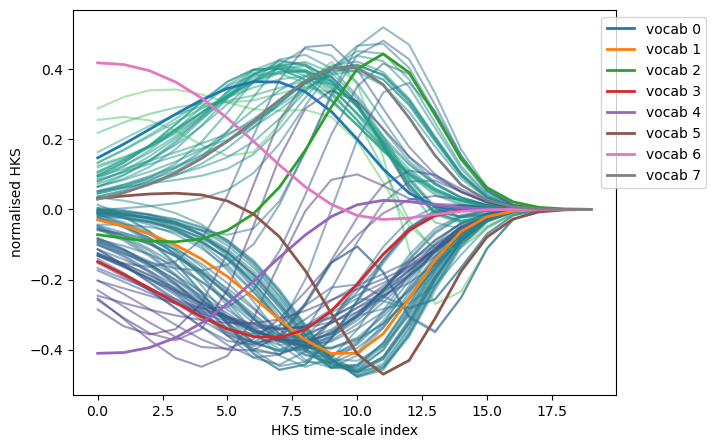

In [60]:
from matplotlib.colors import Normalize
from matplotlib import cm

random_indices = np.random.choice(normalised_hks.shape[0], size=100, replace=False)
norm = Normalize(vmin=normalised_hks[:, 0].min(), vmax=normalised_hks[:, 0].max())
cmap = cm.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(7, 5))
for ind in random_indices:
    ax.plot(normalised_hks[ind], color=cmap(norm(normalised_hks[ind, 0])), alpha=0.5)
for i, center in enumerate(vocab):
    ax.plot(center, '-', linewidth=2, label=f'vocab {i}')
ax.set_xlabel('HKS time-scale index'); ax.set_ylabel('normalised HKS')
plt.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=10)
plt.show()

In [61]:
for i in range(vocab.shape[0]):
    plot(m.v, m.f, c=encoding[:, i])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.281093…

## Save all encodings to a single `.vtp`

Write the PCA-aligned mesh with every per-vertex encoding attached as a point-data array —
the cell fates, the HKS at each diffusion time, and each bag-of-features word — so the whole
organoid can be inspected (e.g. in ParaView or `inspect_embedding.py`) with any encoding as the
colour field.

In [62]:
def save_vtp(path, v, f, point_fields):
    """Write a triangle mesh with named per-vertex scalar arrays to a .vtp."""
    pts = vtk.vtkPoints()
    for p in v:
        pts.InsertNextPoint(float(p[0]), float(p[1]), float(p[2]))
    polys = vtk.vtkCellArray()
    for tri in f:
        cell = vtk.vtkTriangle()
        for j in range(3):
            cell.GetPointIds().SetId(j, int(tri[j]))
        polys.InsertNextCell(cell)
    pd = vtk.vtkPolyData()
    pd.SetPoints(pts)
    pd.SetPolys(polys)
    for name, arr in point_fields.items():
        va = numpy_to_vtk(np.ascontiguousarray(np.asarray(arr, dtype=np.float64)), deep=True)
        va.SetName(name)
        pd.GetPointData().AddArray(va)
    writer = vtk.vtkXMLPolyDataWriter()
    writer.SetFileName(path)
    writer.SetInputData(pd)
    writer.Write()


point_fields = {}
point_fields.update({f'fate_{n}': v for n, v in fate_fields.items()})   # cell fates
point_fields.update({f'hks_t{t}': hks[:, k] for k, t in enumerate(SPARSE_TS)})   # HKS
point_fields.update({f'bof_word{i}': encoding[:, i] for i in range(encoding.shape[1])})   # bag-of-features

out_vtp = f'sim/encodings_{uid}.vtp'
save_vtp(out_vtp, m.v, m.f, point_fields)
print(f'wrote {len(point_fields)} encodings -> {out_vtp}')
for name in point_fields:
    print('  ', name)

wrote 21 encodings -> sim/encodings_main_dataset_day4p5-more_C03_161.vtp
   fate_lgr
   fate_chroma
   fate_ta
   fate_muc
   fate_aldob
   fate_gluc
   fate_agr
   fate_sero
   fate_lyz
   hks_t1
   hks_t4
   hks_t25
   hks_t100
   bof_word0
   bof_word1
   bof_word2
   bof_word3
   bof_word4
   bof_word5
   bof_word6
   bof_word7
